In [1]:

import re
import ssl
import string

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import RegexpTokenizer, word_tokenize

try:
    _create_unverified_https_context = ssl._create_unverified_context
    ssl._create_default_https_context = _create_unverified_https_context
except AttributeError:
    pass
#ako su potrebne instalacije 
#nltk.download("stopwords")
#nltk.download("wordnet")


from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import clone


from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MaxAbsScaler
from sklearn.decomposition import TruncatedSVD


from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import  ComplementNB
from sklearn.ensemble import RandomForestClassifier


from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
)


import joblib

In [2]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return " ".join(words)

In [3]:
data=pd.read_csv('../../Reviews.csv')
data.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [4]:
data_small, _ = train_test_split(
    data,
    train_size=100000,
    stratify=data["Score"],
    random_state=42
)
data_small["Score"].value_counts()

Score
5    63879
4    14188
1     9195
3     7501
2     5237
Name: count, dtype: int64

In [5]:
data_small["TextFull"] = data_small["Summary"].fillna("") + " " + data_small["Text"].fillna("")
data_small["HelpfulnessRatio"] = data_small["HelpfulnessNumerator"] / (data_small["HelpfulnessDenominator"] + 1e-9)


In [6]:
data_small["cleaned_full"] = data_small["TextFull"].apply(clean_text)
num_cols = ["HelpfulnessNumerator", "HelpfulnessDenominator", "HelpfulnessRatio"]

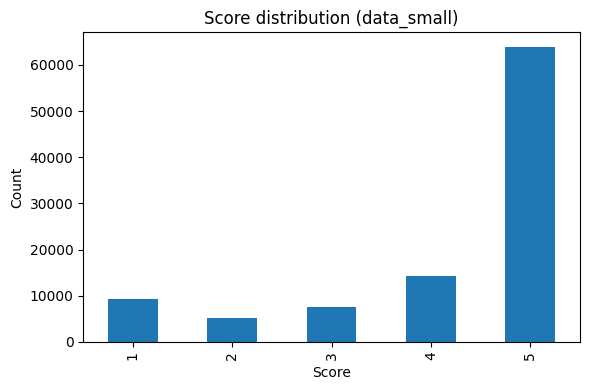

In [7]:
plt.figure(figsize=(6,4))
data_small["Score"].value_counts().sort_index().plot(kind="bar")
plt.title("Score distribution (data_small)")
plt.xlabel("Score")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

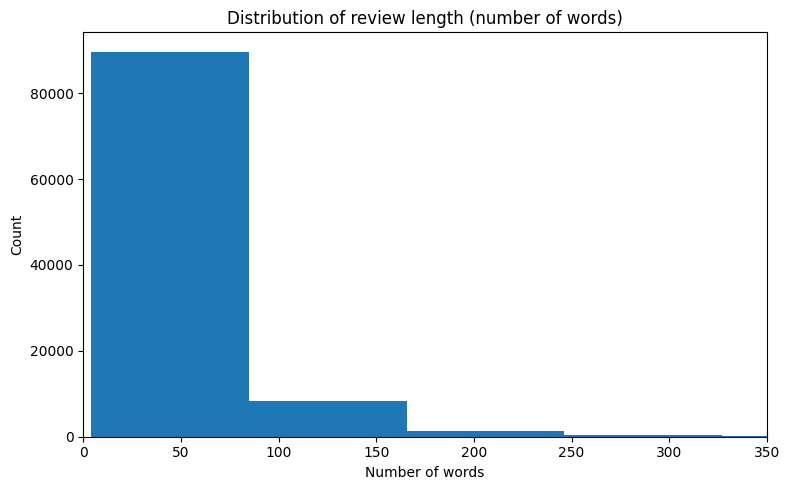

In [8]:
data_small["text_length"] = data_small["cleaned_full"].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8,5))

plt.hist(data_small["text_length"], bins=25)
plt.xlim(0, 350)   # ograničimo raspon

plt.title("Distribution of review length (number of words)")
plt.xlabel("Number of words")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [9]:
text_col = "cleaned_full"
num_cols = ["HelpfulnessNumerator", "HelpfulnessDenominator", "HelpfulnessRatio"]

In [10]:
data_small.to_csv("processed_reviews.csv", index=False)
print("Processed dataset saved.")

Processed dataset saved.


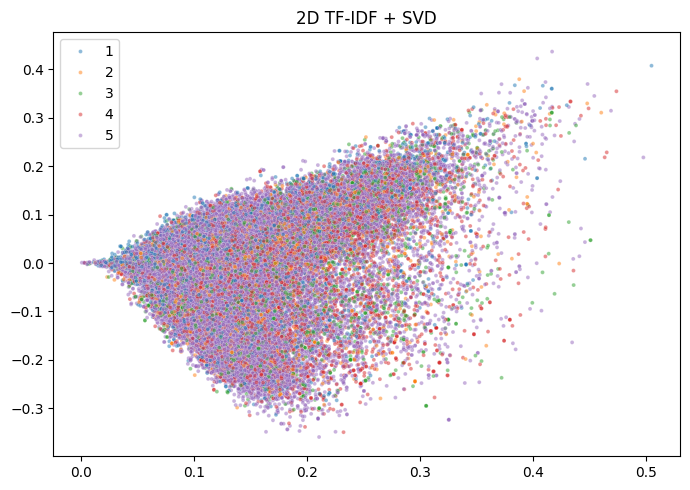

In [11]:
tfidf_vis = TfidfVectorizer(max_features=20000, ngram_range=(1,2), min_df=2)
X_tfidf = tfidf_vis.fit_transform(data_small["cleaned_full"].fillna(""))
y_vis = data_small["Score"].astype(int).values

svd2 = TruncatedSVD(n_components=2, random_state=42)
X2 = svd2.fit_transform(X_tfidf)

plt.figure(figsize=(7,5))
sns.scatterplot(x=X2[:,0], y=X2[:,1], hue=y_vis, palette="tab10", s=8, alpha=0.5)
plt.title("2D TF-IDF + SVD")
plt.tight_layout()
plt.show()

Explained variance ratio (sum): 0.016870154858191592


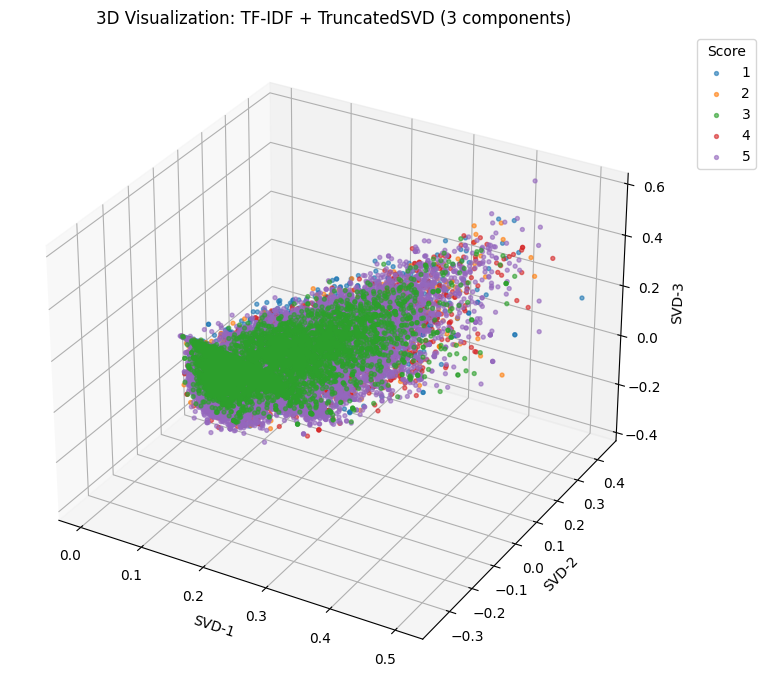

In [12]:
texts = data_small["cleaned_full"].fillna("")
y = data_small["Score"].astype(int).values

# TF-IDF (isti princip kao u modelima)
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_3d = TfidfVectorizer(
    ngram_range=(1,2),
    max_features=20000,
    min_df=2
)

X_tfidf = tfidf_3d.fit_transform(texts)

# SVD na 3 komponente
svd3 = TruncatedSVD(n_components=3, random_state=42)
X_3d = svd3.fit_transform(X_tfidf)

print("Explained variance ratio (sum):", svd3.explained_variance_ratio_.sum())

# 3D scatter
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

classes = np.sort(np.unique(y))
for c in classes:
    idx = (y == c)
    ax.scatter(
        X_3d[idx, 0],
        X_3d[idx, 1],
        X_3d[idx, 2],
        s=8,
        alpha=0.6,
        label=str(c)
    )

ax.set_title("3D Visualization: TF-IDF + TruncatedSVD (3 components)")
ax.set_xlabel("SVD-1")
ax.set_ylabel("SVD-2")
ax.set_zlabel("SVD-3")
ax.legend(title="Score", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [13]:
X = data_small[["cleaned_full", "HelpfulnessNumerator", "HelpfulnessDenominator", "HelpfulnessRatio"]]
y = data_small["Score"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [14]:
train_df = X_train.copy()
train_df["Score"] = y_train.values

min_count = train_df["Score"].value_counts().min()

train_bal = (
    train_df.groupby("Score", group_keys=False)
    .apply(lambda g: g.sample(min_count, random_state=42))
)

X_train_bal = train_bal.drop(columns=["Score"])
y_train_bal = train_bal["Score"]

In [15]:

def make_preprocessor(max_features=20000):
    tfidf = TfidfVectorizer(max_features=max_features, ngram_range=(1,2), min_df=2)
    return ColumnTransformer(
        transformers=[
            ("text", Pipeline([("tfidf", tfidf)]), text_col),
            ("num", MaxAbsScaler(), num_cols)
        ],
        remainder="drop"
    )

In [16]:
models = {
    "LinearSVC": LinearSVC(dual="auto", max_iter=5000),
    "SGD hinge": SGDClassifier(loss="hinge", random_state=42),
    "LogReg": LogisticRegression(max_iter=500, n_jobs=-1),
    "Random forest": RandomForestClassifier(n_estimators=300,max_depth=30,max_features="sqrt",min_samples_split=5,n_jobs=-1,
    random_state=42),
    "ComplementNB": ComplementNB(),
}

def run_block(Xtr, Xte, ytr, yte, dataset_label, max_features):
    pre = make_preprocessor(max_features=max_features)
    rows = []
    
    total_models = len(models)
    
    print(f"\n=== Dataset: {dataset_label} | TFIDF: {max_features} ===")
    
    for i, (name, model) in enumerate(models.items(), 1):
        print(f"[{i}/{total_models}] Trening modela: {name} ...", end=" ")
        
        pipe = Pipeline([("pre", pre), ("clf", model)])
        pipe.fit(Xtr, ytr)
        pred = pipe.predict(Xte)
        
        acc = accuracy_score(yte, pred)
        f1m = f1_score(yte, pred, average="macro")
        f1w = f1_score(yte, pred, average="weighted")
        
        print(f"done | Acc={acc:.4f} | F1_macro={f1m:.4f}| F1_weighted={f1w:.4f}")
        
        rows.append({
            "Dataset": dataset_label,
            "TFIDF": f"{max_features}",
            "Model": name,
            "Accuracy": acc,
            "F1_macro": f1m,
            "F1_weighted": f1w
        })
        
    return rows

In [17]:
rows = []
for k in [10000, 20000]:
    rows += run_block(X_train, X_test, y_train, y_test, "RAW", k)
    rows += run_block(X_train_bal, X_test, y_train_bal, y_test, "BAL", k)

results_df = pd.DataFrame(rows).sort_values("F1_macro", ascending=False)
results_df


=== Dataset: RAW | TFIDF: 10000 ===
[1/5] Trening modela: LinearSVC ... done | Acc=0.7513 | F1_macro=0.5366| F1_weighted=0.7264
[2/5] Trening modela: SGD hinge ... done | Acc=0.7141 | F1_macro=0.3873| F1_weighted=0.6358
[3/5] Trening modela: LogReg ... done | Acc=0.7490 | F1_macro=0.5192| F1_weighted=0.7172
[4/5] Trening modela: Random forest ... done | Acc=0.6552 | F1_macro=0.2237| F1_weighted=0.5332
[5/5] Trening modela: ComplementNB ... done | Acc=0.6922 | F1_macro=0.4563| F1_weighted=0.6830

=== Dataset: BAL | TFIDF: 10000 ===
[1/5] Trening modela: LinearSVC ... done | Acc=0.6092 | F1_macro=0.4917| F1_weighted=0.6410
[2/5] Trening modela: SGD hinge ... done | Acc=0.6812 | F1_macro=0.5196| F1_weighted=0.6931
[3/5] Trening modela: LogReg ... done | Acc=0.6321 | F1_macro=0.5120| F1_weighted=0.6610
[4/5] Trening modela: Random forest ... done | Acc=0.6600 | F1_macro=0.5079| F1_weighted=0.6740
[5/5] Trening modela: ComplementNB ... done | Acc=0.6532 | F1_macro=0.4876| F1_weighted=0.666

,Dataset,TFIDF,Model,Accuracy,F1_macro,F1_weighted
10,RAW,20000,LinearSVC,0.75635,0.559637,0.736228
0,RAW,10000,LinearSVC,0.75135,0.536646,0.726412
12,RAW,20000,LogReg,0.75230,0.525963,0.719845
16,BAL,20000,SGD hinge,0.68310,0.525937,0.695030
6,BAL,10000,SGD hinge,0.68115,0.519554,0.693106
2,RAW,10000,LogReg,0.74905,0.519152,0.717154
17,BAL,20000,LogReg,0.63760,0.517542,0.665995
7,BAL,10000,LogReg,0.63210,0.511962,0.661017
18,BAL,20000,Random forest,0.66520,0.511670,0.677564
8,BAL,10000,Random forest,0.65995,0.507877,0.673979


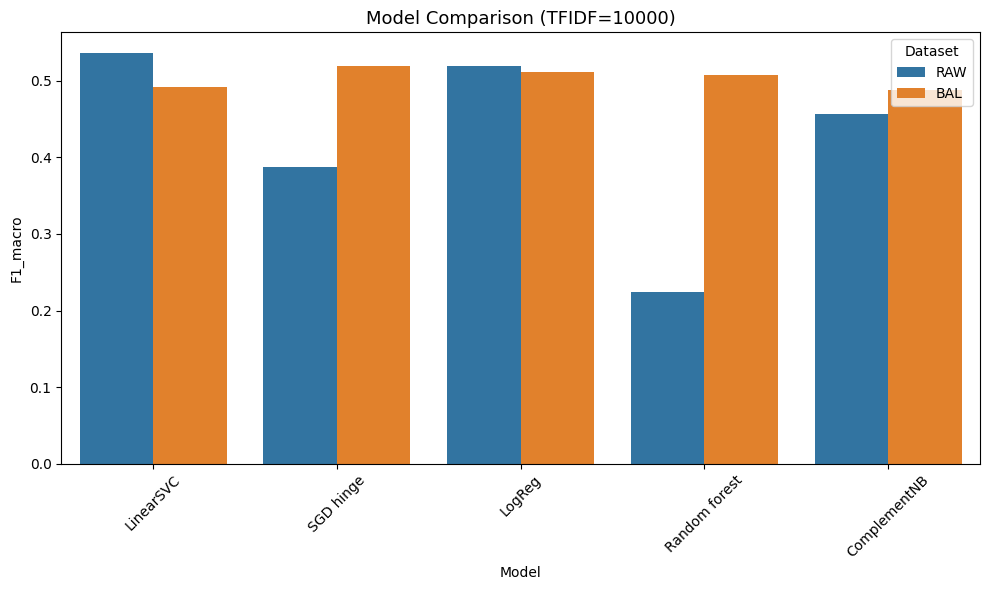

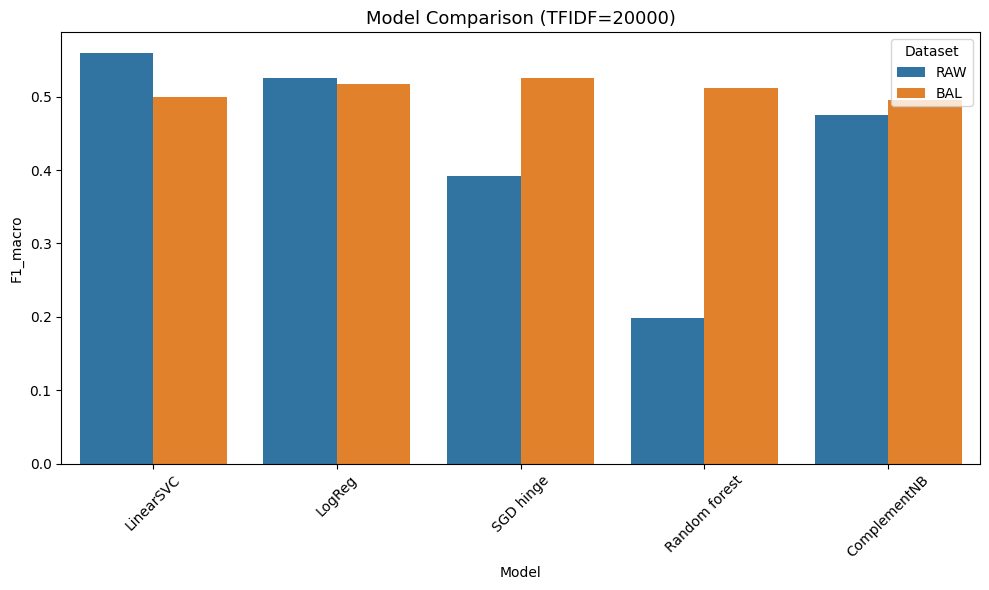

In [48]:
for tfidf_name in ["10000", "20000"]:
    plt.figure(figsize=(10,6))
    
    sub = results_df[results_df["TFIDF"] == tfidf_name]
    
    sns.barplot(
        data=sub,
        x="Model",
        y="F1_macro",
        hue="Dataset",
    )
    
    plt.xticks(rotation=45)
    plt.title(f"Model Comparison (TFIDF={tfidf_name})", fontsize=13)
    plt.tight_layout()
    plt.show()

In [46]:
def show_cm_raw_vs_bal_for_model(
    model_name,
    max_features,
    X_train, y_train,
    X_train_bal, y_train_bal,
    X_test, y_test,
    title_prefix="SCORE",
    normalize="true"

):
    
    pre = make_preprocessor(max_features=max_features)

    print("="*90)
    print(f"{title_prefix} | Model: {model_name} | TFIDF: {max_features}")
    print("="*90)

    pipe_raw = Pipeline([("pre", pre), ("clf", models[model_name])])
    pipe_raw.fit(X_train, y_train)

    pred_raw_tr = pipe_raw.predict(X_train)
    pred_raw_te = pipe_raw.predict(X_test)

    cm_raw_tr = confusion_matrix(y_train, pred_raw_tr, normalize=normalize)
    cm_raw_te = confusion_matrix(y_test,  pred_raw_te, normalize=normalize)

    # --- BAL ---
    pipe_bal = Pipeline([("pre", pre), ("clf", models[model_name])])
    pipe_bal.fit(X_train_bal, y_train_bal)

    pred_bal_tr = pipe_bal.predict(X_train_bal)
    pred_bal_te = pipe_bal.predict(X_test)

    cm_bal_tr = confusion_matrix(y_train_bal, pred_bal_tr,  normalize=normalize)
    cm_bal_te = confusion_matrix(y_test,      pred_bal_te,  normalize=normalize)

    # --- Plot 2x2 ---
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    ConfusionMatrixDisplay(cm_raw_tr).plot(ax=axes[0,0], cmap="Blues", colorbar=False)
    axes[0,0].set_title("RAW | TRAIN")
    axes[0,0].grid(False)

    ConfusionMatrixDisplay(cm_raw_te).plot(ax=axes[0,1], cmap="Blues", colorbar=False)
    axes[0,1].set_title("RAW | TEST")
    axes[0,1].grid(False)

    ConfusionMatrixDisplay(cm_bal_tr).plot(ax=axes[1,0], cmap="Blues", colorbar=False)
    axes[1,0].set_title("BAL | TRAIN")
    axes[1,0].grid(False)

    ConfusionMatrixDisplay(cm_bal_te).plot(ax=axes[1,1], cmap="Blues", colorbar=False)
    axes[1,1].set_title("BAL | TEST")
    axes[1,1].grid(False)

    plt.suptitle(f"{title_prefix}: {model_name} | TFIDF {max_features}", fontsize=14)
    plt.tight_layout()
    plt.show()

    # --- Reports ---
    print("\n--- RAW | TRAIN report ---")
    print(classification_report(y_train, pred_raw_tr))

    print("\n--- RAW | TEST report ---")
    print(classification_report(y_test, pred_raw_te))

    print("\n--- BAL | TRAIN report ---")
    print(classification_report(y_train_bal, pred_bal_tr))

    print("\n--- BAL | TEST report ---")
    print(classification_report(y_test, pred_bal_te))

SCORE | Model: LinearSVC | TFIDF: 20000


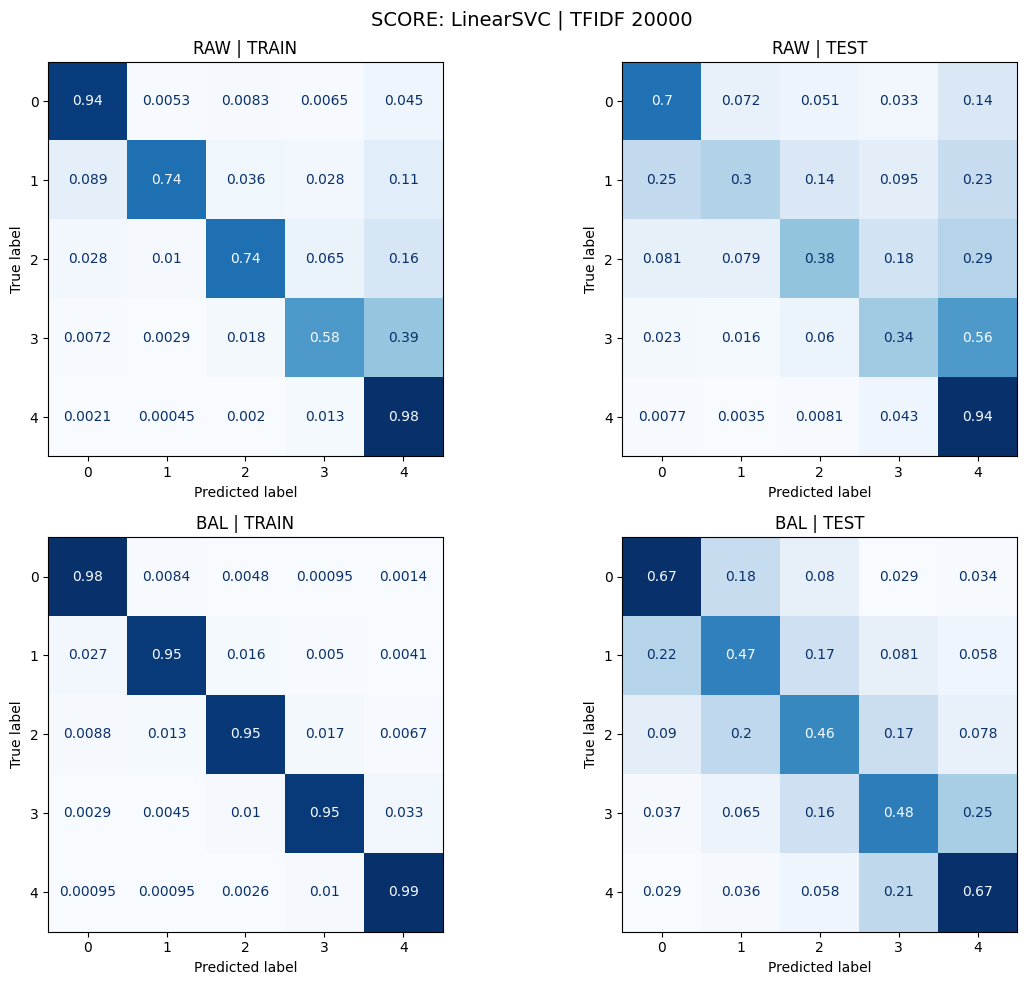


--- RAW | TRAIN report ---
              precision    recall  f1-score   support

           1       0.90      0.94      0.92      7356
           2       0.95      0.74      0.83      4190
           3       0.90      0.74      0.81      6001
           4       0.84      0.58      0.69     11350
           5       0.89      0.98      0.93     51103

    accuracy                           0.89     80000
   macro avg       0.90      0.80      0.84     80000
weighted avg       0.89      0.89      0.88     80000


--- RAW | TEST report ---
              precision    recall  f1-score   support

           1       0.70      0.70      0.70      1839
           2       0.48      0.30      0.37      1047
           3       0.53      0.38      0.44      1500
           4       0.50      0.34      0.41      2838
           5       0.83      0.94      0.88     12776

    accuracy                           0.76     20000
   macro avg       0.61      0.53      0.56     20000
weighted avg       0.7

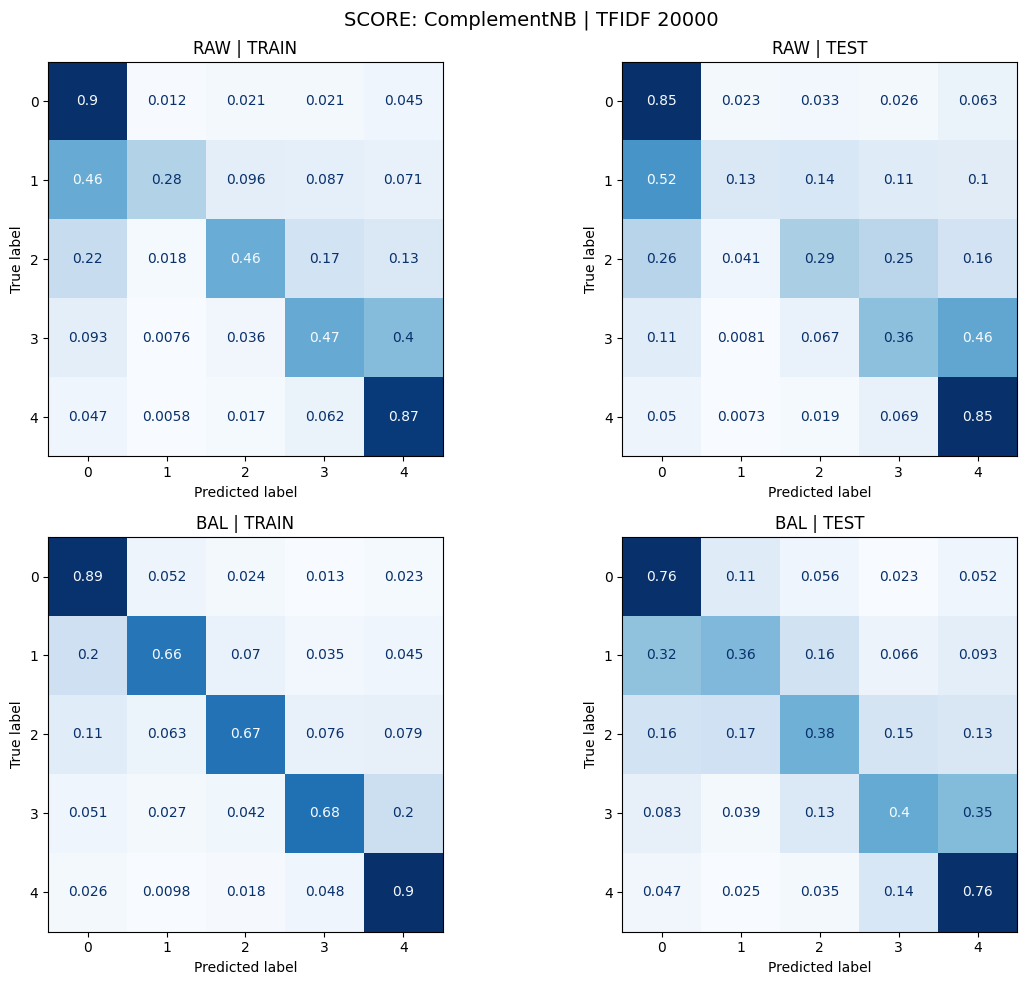


--- RAW | TRAIN report ---
              precision    recall  f1-score   support

           1       0.50      0.90      0.64      7356
           2       0.67      0.28      0.40      4190
           3       0.60      0.46      0.52      6001
           4       0.53      0.47      0.50     11350
           5       0.88      0.87      0.87     51103

    accuracy                           0.75     80000
   macro avg       0.64      0.60      0.59     80000
weighted avg       0.76      0.75      0.75     80000


--- RAW | TEST report ---
              precision    recall  f1-score   support

           1       0.46      0.85      0.59      1839
           2       0.38      0.13      0.19      1047
           3       0.41      0.29      0.34      1500
           4       0.42      0.36      0.39      2838
           5       0.86      0.85      0.86     12776

    accuracy                           0.70     20000
   macro avg       0.50      0.50      0.47     20000
weighted avg       0.7

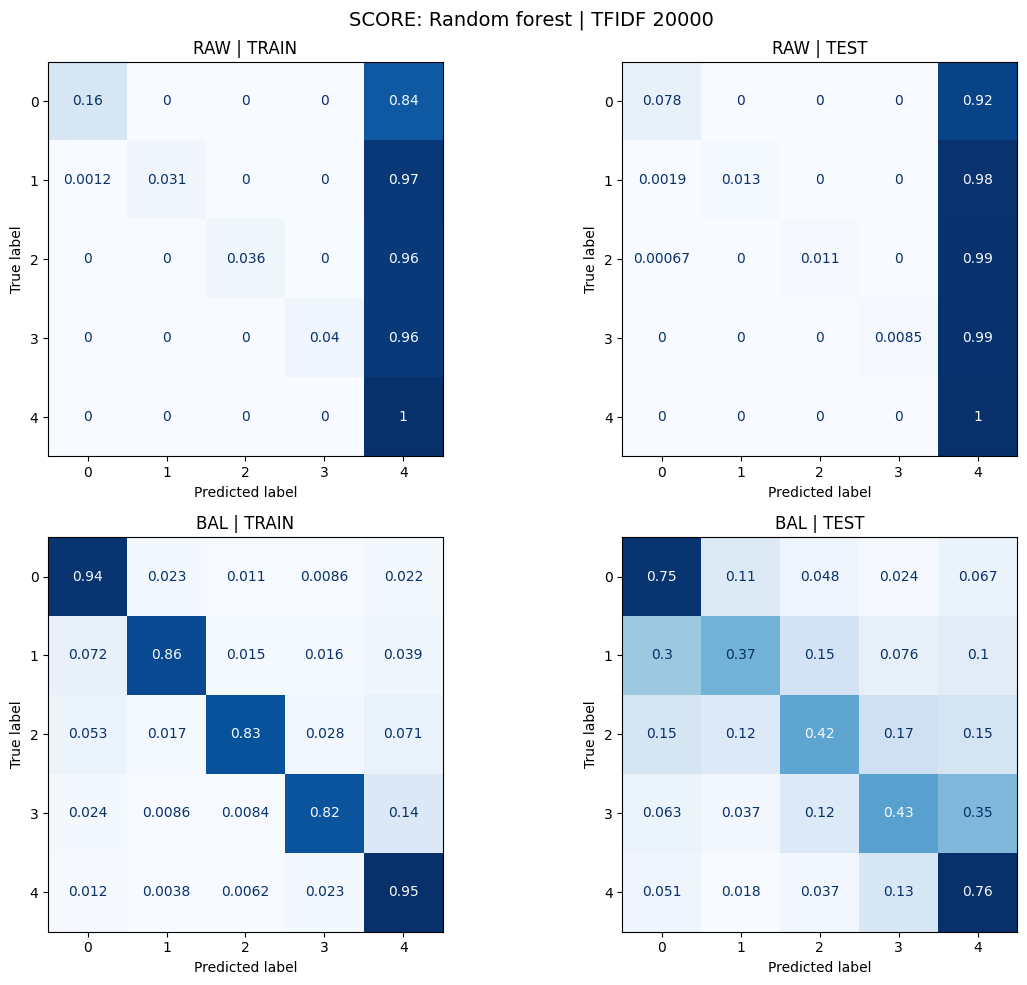


--- RAW | TRAIN report ---
              precision    recall  f1-score   support

           1       1.00      0.16      0.27      7356
           2       1.00      0.03      0.06      4190
           3       1.00      0.04      0.07      6001
           4       1.00      0.04      0.08     11350
           5       0.65      1.00      0.79     51103

    accuracy                           0.66     80000
   macro avg       0.93      0.25      0.25     80000
weighted avg       0.78      0.66      0.55     80000


--- RAW | TEST report ---
              precision    recall  f1-score   support

           1       0.98      0.08      0.14      1839
           2       1.00      0.01      0.03      1047
           3       1.00      0.01      0.02      1500
           4       1.00      0.01      0.02      2838
           5       0.65      1.00      0.78     12776

    accuracy                           0.65     20000
   macro avg       0.92      0.22      0.20     20000
weighted avg       0.7

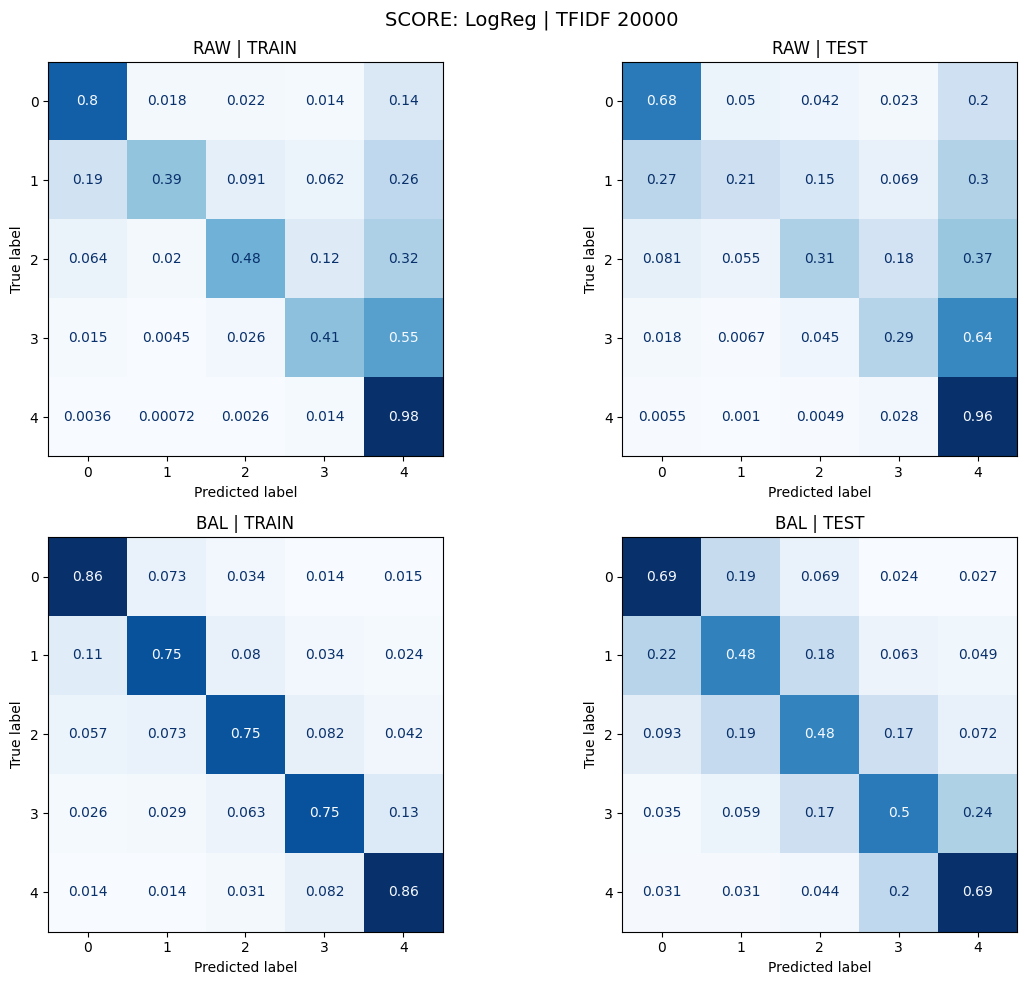


--- RAW | TRAIN report ---
              precision    recall  f1-score   support

           1       0.79      0.80      0.80      7356
           2       0.83      0.39      0.53      4190
           3       0.75      0.48      0.58      6001
           4       0.72      0.41      0.52     11350
           5       0.83      0.98      0.90     51103

    accuracy                           0.81     80000
   macro avg       0.78      0.61      0.67     80000
weighted avg       0.80      0.81      0.79     80000


--- RAW | TEST report ---
              precision    recall  f1-score   support

           1       0.70      0.68      0.69      1839
           2       0.51      0.21      0.29      1047
           3       0.53      0.31      0.39      1500
           4       0.53      0.29      0.37      2838
           5       0.80      0.96      0.87     12776

    accuracy                           0.75     20000
   macro avg       0.61      0.49      0.53     20000
weighted avg       0.7

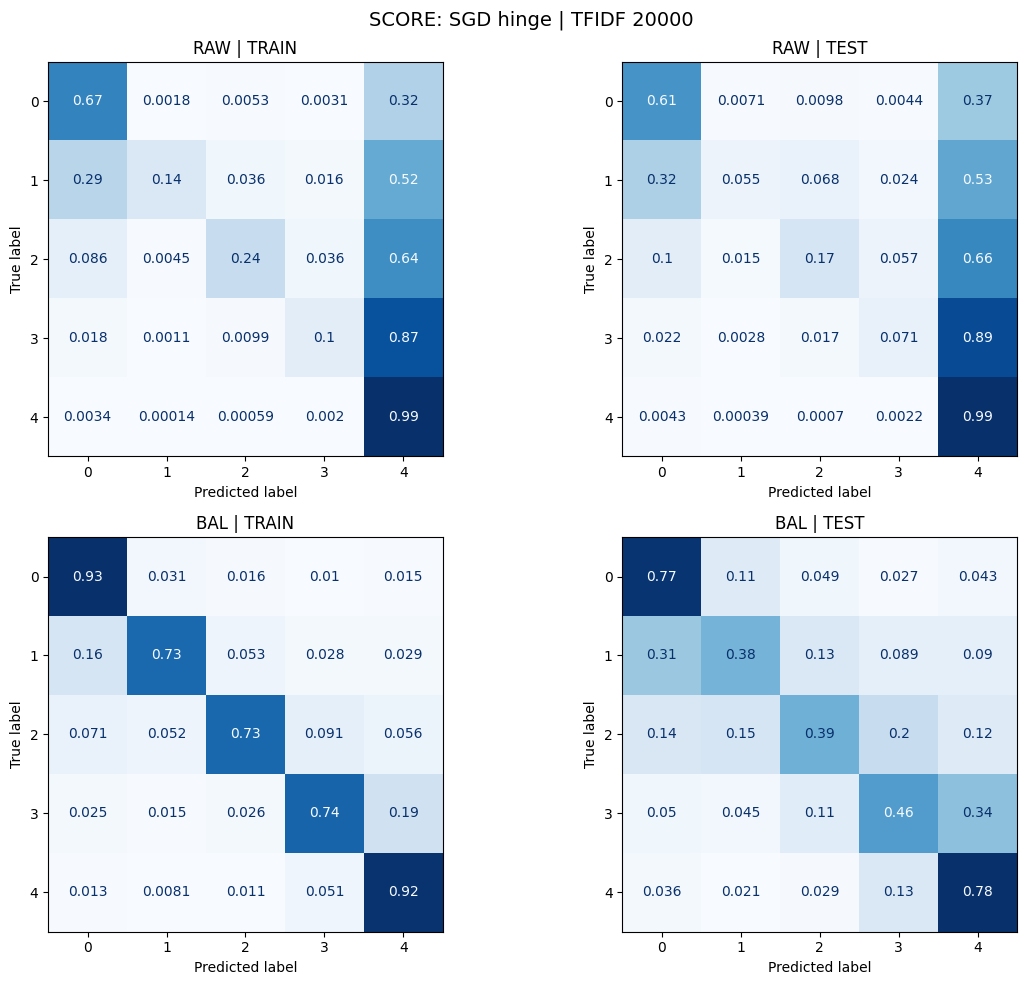


--- RAW | TRAIN report ---
              precision    recall  f1-score   support

           1       0.70      0.67      0.69      7356
           2       0.91      0.14      0.25      4190
           3       0.81      0.24      0.37      6001
           4       0.74      0.10      0.18     11350
           5       0.74      0.99      0.85     51103

    accuracy                           0.74     80000
   macro avg       0.78      0.43      0.47     80000
weighted avg       0.75      0.74      0.67     80000


--- RAW | TEST report ---
              precision    recall  f1-score   support

           1       0.65      0.61      0.63      1839
           2       0.55      0.06      0.10      1047
           3       0.63      0.17      0.27      1500
           4       0.58      0.07      0.13      2838
           5       0.73      0.99      0.84     12776

    accuracy                           0.72     20000
   macro avg       0.63      0.38      0.39     20000
weighted avg       0.6

In [49]:
chosen_models = ["LinearSVC", "ComplementNB", "Random forest","LogReg","SGD hinge"]

for m in chosen_models:
    show_cm_raw_vs_bal_for_model(
        model_name=m,
        max_features=20000,
        X_train=X_train, y_train=y_train,
        X_train_bal=X_train_bal, y_train_bal=y_train_bal,
        X_test=X_test, y_test=y_test,
        title_prefix="SCORE",
    )

In [21]:
best = results_df.sort_values("F1_macro", ascending=False).iloc[0]

best_dataset = best["Dataset"]         
best_k = int(best["TFIDF"])             
best_model_name = best["Model"]         

print("BEST CONFIG:", best.to_dict())

pre = make_preprocessor(max_features=best_k)
pipe = Pipeline([
    ("pre", pre),
    ("clf", models[best_model_name])
])

# 3) Fit na odgovarajući trening skup
if best_dataset == "RAW":
    pipe.fit(X_train, y_train)
else:
    pipe.fit(X_train_bal, y_train_bal)

ct = pipe.named_steps["pre"]
clf = pipe.named_steps["clf"]

tfidf = ct.named_transformers_["text"].named_steps["tfidf"]
text_names = tfidf.get_feature_names_out()

num_names = np.array(["HelpfulnessNumerator", "HelpfulnessDenominator", "HelpfulnessRatio"])
feature_names = np.concatenate([text_names, num_names])

top_n = 10
classes = clf.classes_

table = {}
for i, cls in enumerate(classes):
    coef = clf.coef_[i] 
    top_idx = np.argsort(coef)[-top_n:][::-1]
    table[f"Score_{cls}"] = feature_names[top_idx]

final_df = pd.DataFrame(table)
final_df

BEST CONFIG: {'Dataset': 'RAW', 'TFIDF': '20000', 'Model': 'LinearSVC', 'Accuracy': 0.75635, 'F1_macro': 0.5596368306690568, 'F1_weighted': 0.736228051861285}


,Score_1,Score_2,Score_3,Score_4,Score_5
0,HelpfulnessDenominator,two star,three star,four star,HelpfulnessNumerator
1,worst,nearly good,okay,reason give,best
2,one star,might good,ok,star instead,love
3,awful,meh,bit disappointed,star,excellent
4,disgusting,HelpfulnessDenominator,experimenting,complaint,great
5,terrible,expires,get wrong,reason gave,delicious
6,rip,unfortunately,bad great,tend eat,awesome
7,garbage,completely different,nitrite,gave star,perfect
8,horrible,coffee weak,good great,find cup,amazing
9,thought great,mediocre,hit miss,would given,fantastic


In [ ]:
joblib.dump(pipe, "best_model.joblib")

print("Model uspešno sačuvan kao best_model.joblib")